## 1. Get dataset (`FER 2013`), helper functions, modules, prepare data and dataloaders

### Import the modules and helper functions, make Invokes


we'll use summary for getting model summary, tensor board for logging and graphs of loss, accuracy, accuracy for calculating accuracy

In Invokes we'll mount drive for saving to and loading from models and results saved in drive

#### Imports

In [20]:
import torch
import torchvision
from torchvision import models
from torch import nn

try:
  from torchinfo import summary
  from torch.utils.tensorboard import SummaryWriter
  from ignite.metrics import Accuracy
  from calflops import calculate_flops
  import timm
except:
  !pip install torchinfo
  !pip install -q tensorboard
  !pip install pytorch-ignite
  !pip install calflops
  !pip install timm

  from torchinfo import summary
  from torch.utils.tensorboard import SummaryWriter
  from ignite.metrics import Accuracy
  from calflops import calculate_flops
  import timm

In [19]:
try:
  from modules import get_fer2013_data
  from modules import create_dataloaders
  from modules import evaluate_model_performance
  from helper_functions import train_step, test_step, train, print_train_time, eval_model, save_model_results, load_saved_checkpoint
except:
  !git clone https://github.com/Faizan-Rashid/facial-emotion-recognition-deep-learning.git
  !mv facial-emotion-recognition-deep-learning/modules .
  !mv facial-emotion-recognition-deep-learning/helper_functions.py .
  !rm -rf facial-emotion-recognition-deep-learning
  # Import functions again
  from modules import get_fer2013_data
  from modules import create_dataloaders
  from modules import evaluate_model_performance
  from helper_functions import load_saved_checkpoint

#### Invokes

In [16]:
# # mount google drive
# from google.colab import drive

# drive.mount("/content/drive")

In [17]:
# accuracy function
accuracy_fn = Accuracy()

### device agnostic code

In [5]:

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get the `FER 2013` data

In [6]:
image_path = get_fer2013_data.get_fer2013_data(destination="fer 2013",
                 remove_source=True)

zip file not found downloading from kagglehub
Extracted data/fer2013.zip file to data/fer 2013


In [7]:
train_dir = image_path / "train"
test_dir = image_path / "test"

### Prepare the data loaders and transforms for data augumentation

#### prepare transforms

we'll be creating simple transform and one for augumentation

##### transform for augmentation

In [8]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader

### the augumentation pipeline
train_transform_aug = transforms.Compose([

    transforms.Resize((224,224)),

    # MobileNet expects 3 channels
    transforms.Grayscale(num_output_channels=3),

    # Geometric augmentations
    transforms.RandomAffine(
        degrees=20,
        translate=(0.1,0.1),
        scale=(0.9,1.1),
        shear=5,
        interpolation=InterpolationMode.BILINEAR
    ),

    transforms.RandomHorizontalFlip(0.5),

    # Illumination augmentations
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.ToTensor(),

    # Cutout / Random Erasing
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02,0.10),
        ratio=(0.3,3.3),
        value='random'      # <-- before Normalize
    ),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

##### simple transform

In [9]:
# general transform to use for both training and testing split
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # MobileNet expects 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### use `create_dataloaders()` function to make dataloaders, datasets

In [10]:
# well keep num_workers and pin_memory as they are defined
(train_dataloader, test_dataloader, class_names, train_dataset, test_dataset) =  create_dataloaders.create_dataloaders(train_dir=train_dir,
                   test_dir=test_dir,
                   batch_size=32,
                   train_transform=transform,
                   test_transform=transform)

(train_dataloader_aug, test_dataloader, class_names, train_dataset, test_dataset) =  create_dataloaders.create_dataloaders(train_dir=train_dir,
                   test_dir=test_dir,
                   batch_size=32,
                   train_transform=train_transform_aug,
                   test_transform=transform)

train_dataloader, train_dataloader_aug, test_dataloader, class_names, train_dataset, test_dataset

(<torch.utils.data.dataloader.DataLoader at 0x796f1cd30c20>,
 ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'],
 Dataset ImageFolder
     Number of datapoints: 28709
     Root location: data/fer 2013/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                Grayscale(num_output_channels=3)
                RandomAffine(degrees=[-20.0, 20.0], translate=(0.1, 0.1), scale=(0.9, 1.1), shear=[-5.0, 5.0], interpolation=bilinear)
                RandomHorizontalFlip(p=0.5)
                ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=None, hue=None)
                ToTensor()
                RandomErasing(p=0.25, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=random, inplace=False)
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 7178
     Root location: data/

## 2. Load and compare saved trained models

### Import all models

In [33]:
gcvit_xxtiny = timm.create_model(model_name="gcvit_xxtiny",
                               num_classes=len(class_names),
                               pretrained=True).to(device)

mobilevit_xs = timm.create_model(model_name="mobilevit_xs",
                                 num_classes=len(class_names),
                                 pretrained=True).to(device)

vit_tiny_patch16_224 = timm.create_model(model_name="vit_tiny_patch16_224",
                                         pretrained=True,
                                         num_classes=len(class_names)).to(device)

swin_tiny_patch4_window7_224 = timm.create_model(model_name="swin_tiny_patch4_window7_224",
                                                 pretrained=True,
                                                 num_classes=len(class_names)).to(device)

davit_tiny = timm.create_model(model_name="davit_tiny",
                               num_classes=len(class_names),
                               pretrained=True).to(device)

In [12]:
# swin_tiny_patch4_window7_224.head.fc = nn.Linear(in_features=swin_tiny_patch4_window7_224.head.fc.in_features,
#                                                  out_features=len(class_names),
#                                                  bias=True).to(device)

### Load saved models states

In [34]:
gcvit_xxtiny_checkpoint = load_saved_checkpoint(model=gcvit_xxtiny,
                      path="/content/drive/MyDrive/ViTs/gcvit_xxtiny/gcvit_xxtiny[72.19][train_2nd_stage].pt",
                      device=device,
                      optimizer=None,
                      load_trained_params=True)

mobilevit_xs_checkpoint = load_saved_checkpoint(model=mobilevit_xs,
                      path="/content/drive/MyDrive/ViTs/mobilevit_xs/mobilevit_xs[70.31][ReduceLROnPleatue].pt",
                      device=device,
                      optimizer=None,
                      load_trained_params=True)


vit_tiny_patch16_224_checkpoint = load_saved_checkpoint(model=vit_tiny_patch16_224,
                      path="/content/drive/MyDrive/ViTs/vit_tiny_patch16_224/vit_tiny_patch16_224[70.92][label_smoothing_0.15_no_class weights].pt",
                      device=device,
                      optimizer=None,
                      load_trained_params=True)

swin_tiny_patch4_window7_224_checkpoint = load_saved_checkpoint(model=swin_tiny_patch4_window7_224,
                      path="/content/drive/MyDrive/ViTs/swin_tiny_patch4_window7_224/swin_tiny_patch4_window7_224[70.60][freeze_1st_4_blocks_label_smoothing_0.15_lr_5e-5_weight_decay_1e-2].pt",
                      device=device,
                      optimizer=None,
                      load_trained_params=True)

davit_tiny_checkpoint = load_saved_checkpoint(model=davit_tiny,
                      path="/content/drive/MyDrive/ViTs/davit_tiny/davit_tiny[72.05][ReduceLROnPleatue_no_class_weights].pt",
                      device=device,
                      optimizer=None,
                      load_trained_params=True)


🔄 Loaded model weights only.


## 3. Evaluate models' performances and Confusion Matrices

  0%|          | 0/225 [00:00<?, ?it/s]

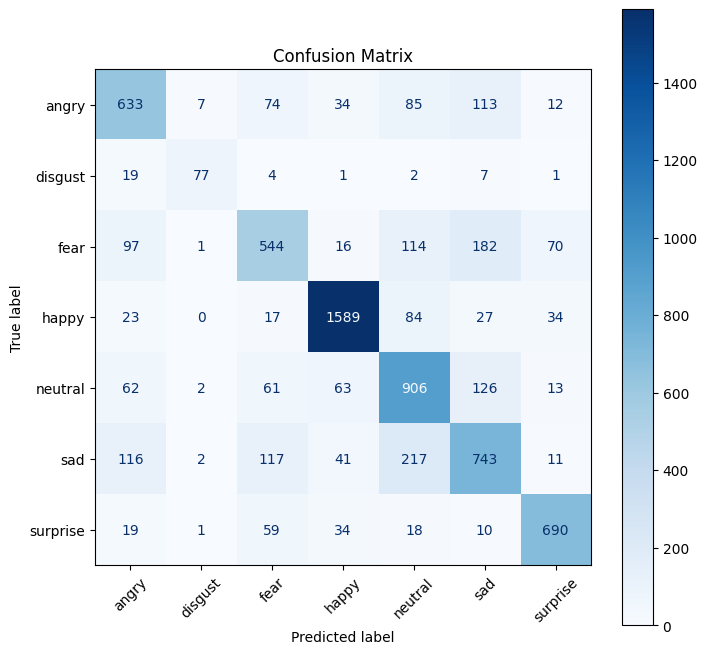

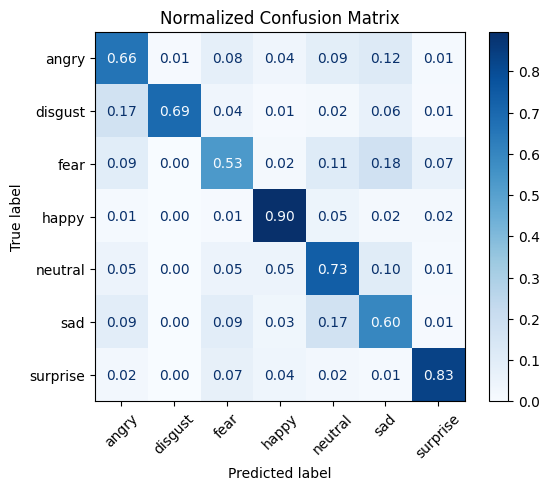


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  11.49 M 
fwd MACs:                                                               1.94 GMACs
fwd FLOPs:                                                              3.9 GFLOPS
fwd+bwd MACs:                                                           5.82 GMACs
fwd+bwd FLOPs:                                                          11.7 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module caculate

{'model_name': 'GlobalContextVit',
 'loss': 0.901505248480373,
 'accuracy': 0.721928113680691,
 'confusion_matrix': array([[ 633,    7,   74,   34,   85,  113,   12],
        [  19,   77,    4,    1,    2,    7,    1],
        [  97,    1,  544,   16,  114,  182,   70],
        [  23,    0,   17, 1589,   84,   27,   34],
        [  62,    2,   61,   63,  906,  126,   13],
        [ 116,    2,  117,   41,  217,  743,   11],
        [  19,    1,   59,   34,   18,   10,  690]]),
 'classwise_accuracy': {'angry': 0.6607515657620042,
  'disgust': 0.6936936936936937,
  'fear': 0.53125,
  'happy': 0.8957158962795941,
  'neutral': 0.7347931873479319,
  'sad': 0.5958299919807538,
  'surprise': 0.8303249097472925},
 'y_true': array([0, 0, 0, ..., 6, 6, 6]),
 'y_pred': array([0, 0, 5, ..., 6, 6, 6]),
 'flops': ('3.9 GFLOPS', '1.94 GMACs', '11.49 M')}

In [21]:
#### evaluating mobilenet_v3_small
gcvit_xxtiny_performance = evaluate_model_performance.evaluate_model_performance(model=gcvit_xxtiny,
                                                            data_loader=test_dataloader,
                                                            loss_fn=nn.CrossEntropyLoss(),
                                                            accuracy_fn=accuracy_fn,
                                                            class_names=class_names,
                                                            calculate_flops=calculate_flops,
                                                            calculate_flops_value=True,
                                                            display_conf_matrix=True)

gcvit_xxtiny_performance

  0%|          | 0/225 [00:00<?, ?it/s]

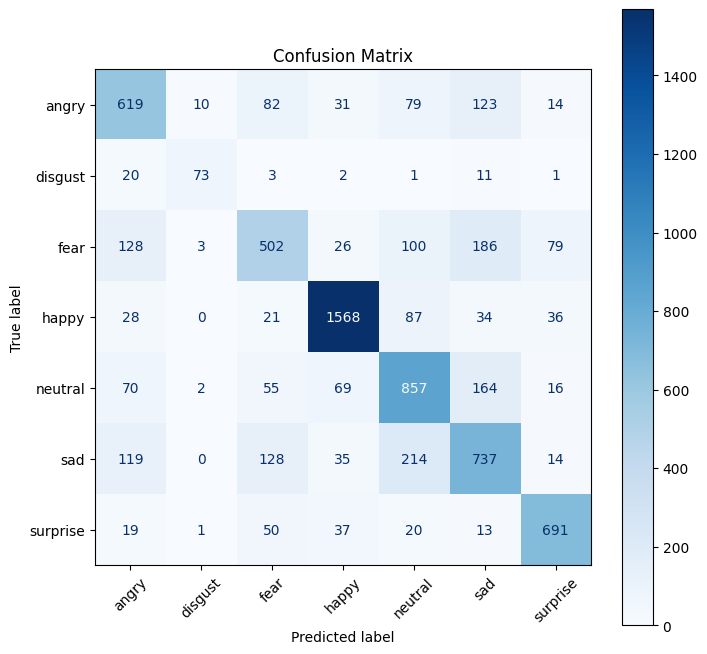

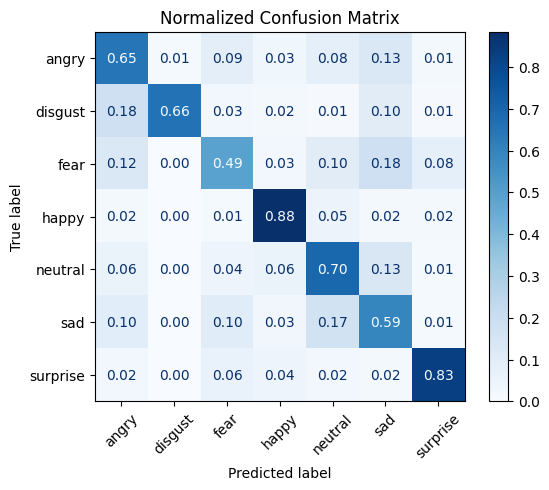


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  1.94 M  
fwd MACs:                                                               702.85 MMACs
fwd FLOPs:                                                              1.43 GFLOPS
fwd+bwd MACs:                                                           2.11 GMACs
fwd+bwd FLOPs:                                                          4.3 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module cacula

{'model_name': 'ByobNet',
 'loss': 0.8810282515154945,
 'accuracy': 0.7031206464196155,
 'confusion_matrix': array([[ 619,   10,   82,   31,   79,  123,   14],
        [  20,   73,    3,    2,    1,   11,    1],
        [ 128,    3,  502,   26,  100,  186,   79],
        [  28,    0,   21, 1568,   87,   34,   36],
        [  70,    2,   55,   69,  857,  164,   16],
        [ 119,    0,  128,   35,  214,  737,   14],
        [  19,    1,   50,   37,   20,   13,  691]]),
 'classwise_accuracy': {'angry': 0.6461377870563675,
  'disgust': 0.6576576576576577,
  'fear': 0.490234375,
  'happy': 0.8838782412626832,
  'neutral': 0.6950527169505272,
  'sad': 0.591018444266239,
  'surprise': 0.8315282791817088},
 'y_true': array([0, 0, 0, ..., 6, 6, 6]),
 'y_pred': array([0, 0, 5, ..., 6, 6, 6]),
 'flops': ('1.43 GFLOPS', '702.85 MMACs', '1.94 M')}

In [22]:
#### evaluating shufflenet_v2_x0_5
mobilevit_xs_performance = evaluate_model_performance.evaluate_model_performance(model=mobilevit_xs,
                                                            data_loader=test_dataloader,
                                                            loss_fn=nn.CrossEntropyLoss(),
                                                            accuracy_fn=accuracy_fn,
                                                            class_names=class_names,
                                                            calculate_flops=calculate_flops,
                                                            calculate_flops_value=True,
                                                            display_conf_matrix=True)

mobilevit_xs_performance

  0%|          | 0/225 [00:00<?, ?it/s]

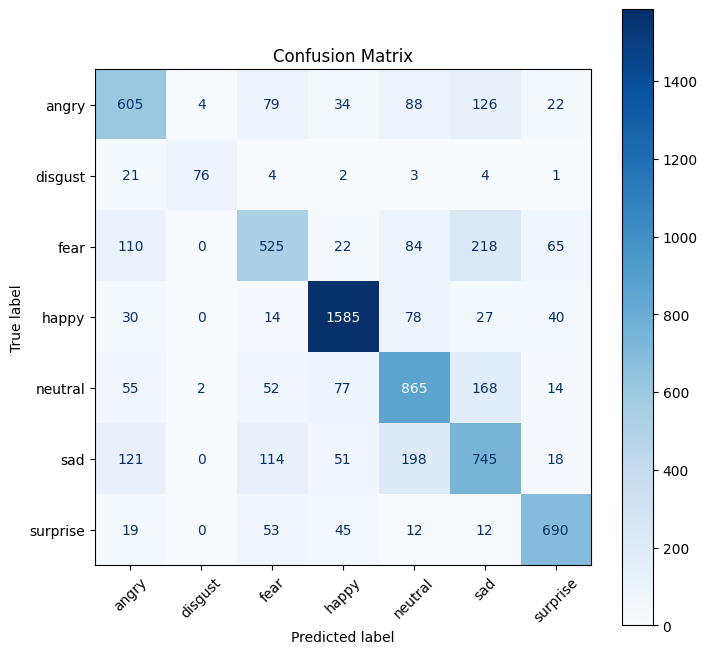

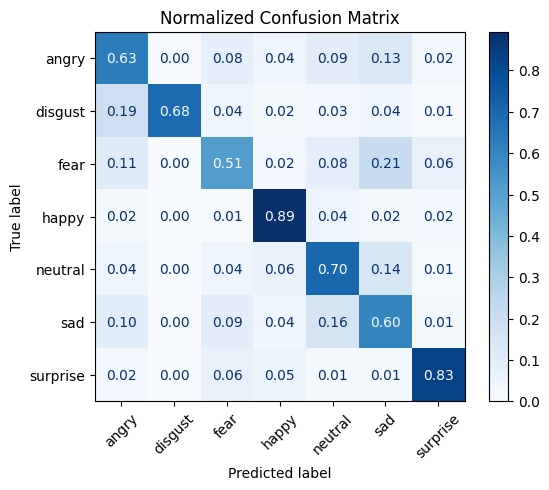


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  5.53 M  
fwd MACs:                                                               1.07 GMACs
fwd FLOPs:                                                              2.16 GFLOPS
fwd+bwd MACs:                                                           3.22 GMACs
fwd+bwd FLOPs:                                                          6.47 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module caculat

{'model_name': 'VisionTransformer',
 'loss': 0.8741914588212967,
 'accuracy': 0.7092504876010031,
 'confusion_matrix': array([[ 605,    4,   79,   34,   88,  126,   22],
        [  21,   76,    4,    2,    3,    4,    1],
        [ 110,    0,  525,   22,   84,  218,   65],
        [  30,    0,   14, 1585,   78,   27,   40],
        [  55,    2,   52,   77,  865,  168,   14],
        [ 121,    0,  114,   51,  198,  745,   18],
        [  19,    0,   53,   45,   12,   12,  690]]),
 'classwise_accuracy': {'angry': 0.6315240083507306,
  'disgust': 0.6846846846846847,
  'fear': 0.5126953125,
  'happy': 0.8934611048478016,
  'neutral': 0.7015409570154095,
  'sad': 0.5974338412189254,
  'surprise': 0.8303249097472925},
 'y_true': array([0, 0, 0, ..., 6, 6, 6]),
 'y_pred': array([0, 0, 5, ..., 6, 6, 6]),
 'flops': ('2.16 GFLOPS', '1.07 GMACs', '5.53 M')}

In [36]:
#### evaluating shufflenet_v2_x1_0
vit_tiny_patch16_224_performance = evaluate_model_performance.evaluate_model_performance(model=vit_tiny_patch16_224,
                                                            data_loader=test_dataloader,
                                                            loss_fn=nn.CrossEntropyLoss(),
                                                            accuracy_fn=accuracy_fn,
                                                            class_names=class_names,
                                                            calculate_flops=calculate_flops,
                                                            calculate_flops_value=True,
                                                            display_conf_matrix=True)

vit_tiny_patch16_224_performance

  0%|          | 0/225 [00:00<?, ?it/s]

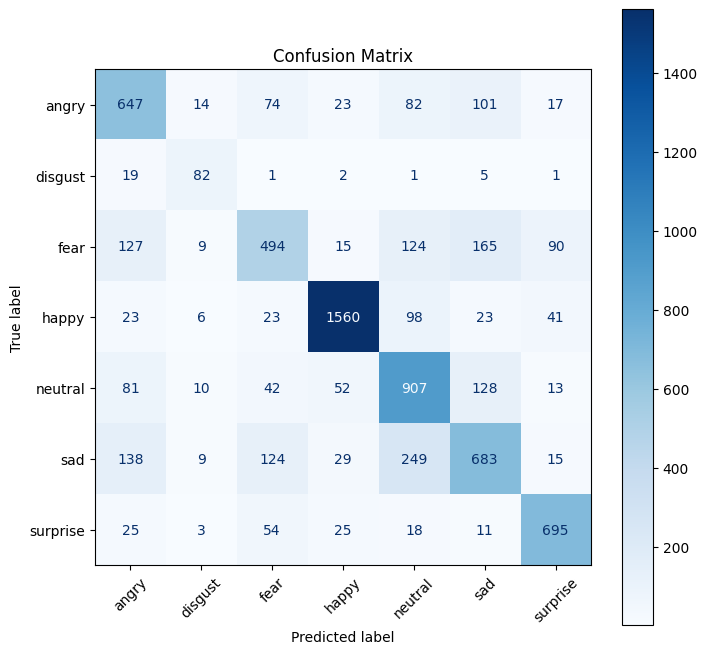

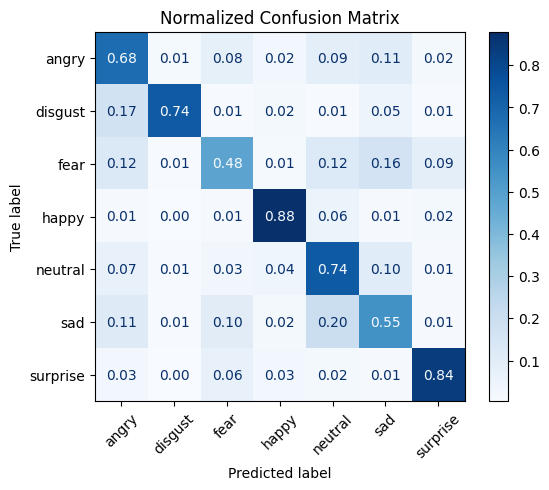


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  27.52 M 
fwd MACs:                                                               4.35 GMACs
fwd FLOPs:                                                              8.73 GFLOPS
fwd+bwd MACs:                                                           13.05 GMACs
fwd+bwd FLOPs:                                                          26.18 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module cacul

{'model_name': 'SwinTransformer',
 'loss': 1.0609434147675831,
 'accuracy': 0.706046252438005,
 'confusion_matrix': array([[ 647,   14,   74,   23,   82,  101,   17],
        [  19,   82,    1,    2,    1,    5,    1],
        [ 127,    9,  494,   15,  124,  165,   90],
        [  23,    6,   23, 1560,   98,   23,   41],
        [  81,   10,   42,   52,  907,  128,   13],
        [ 138,    9,  124,   29,  249,  683,   15],
        [  25,    3,   54,   25,   18,   11,  695]]),
 'classwise_accuracy': {'angry': 0.675365344467641,
  'disgust': 0.7387387387387387,
  'fear': 0.482421875,
  'happy': 0.8793686583990981,
  'neutral': 0.7356042173560422,
  'sad': 0.5477145148356054,
  'surprise': 0.8363417569193743},
 'y_true': array([0, 0, 0, ..., 6, 6, 6]),
 'y_pred': array([0, 0, 5, ..., 6, 6, 6]),
 'flops': ('8.73 GFLOPS', '4.35 GMACs', '27.52 M')}

In [23]:
#### evaluating efficientnet_b0
swin_tiny_patch4_window7_224_performance = evaluate_model_performance.evaluate_model_performance(model=swin_tiny_patch4_window7_224,
                                                            data_loader=test_dataloader,
                                                            loss_fn=nn.CrossEntropyLoss(),
                                                            accuracy_fn=accuracy_fn,
                                                            class_names=class_names,
                                                            calculate_flops=calculate_flops,
                                                            calculate_flops_value=True,
                                                            display_conf_matrix=True)

swin_tiny_patch4_window7_224_performance

  0%|          | 0/225 [00:00<?, ?it/s]

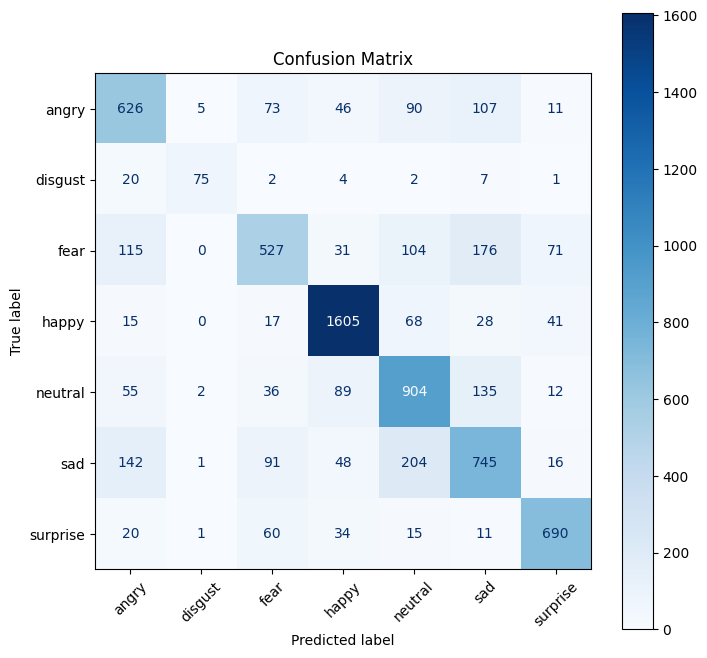

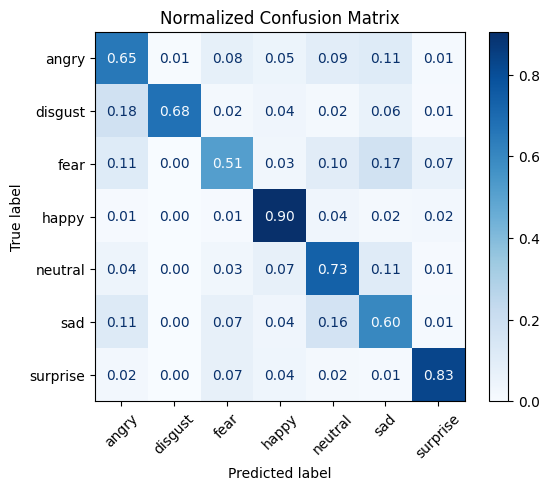


------------------------------------- Calculate Flops Results -------------------------------------
Notations:
number of parameters (Params), number of multiply-accumulate operations(MACs),
number of floating-point operations (FLOPs), floating-point operations per second (FLOPS),
fwd FLOPs (model forward propagation FLOPs), bwd FLOPs (model backward propagation FLOPs),
default model backpropagation takes 2.00 times as much computation as forward propagation.

Total Training Params:                                                  27.6 M  
fwd MACs:                                                               4.41 GMACs
fwd FLOPs:                                                              8.84 GFLOPS
fwd+bwd MACs:                                                           13.22 GMACs
fwd+bwd FLOPs:                                                          26.51 GFLOPS

-------------------------------- Detailed Calculated FLOPs Results --------------------------------
Each module cacul

{'model_name': 'DaVit',
 'loss': 0.8761264638768302,
 'accuracy': 0.7205349679576484,
 'confusion_matrix': array([[ 626,    5,   73,   46,   90,  107,   11],
        [  20,   75,    2,    4,    2,    7,    1],
        [ 115,    0,  527,   31,  104,  176,   71],
        [  15,    0,   17, 1605,   68,   28,   41],
        [  55,    2,   36,   89,  904,  135,   12],
        [ 142,    1,   91,   48,  204,  745,   16],
        [  20,    1,   60,   34,   15,   11,  690]]),
 'classwise_accuracy': {'angry': 0.6534446764091858,
  'disgust': 0.6756756756756757,
  'fear': 0.5146484375,
  'happy': 0.9047350620067643,
  'neutral': 0.7331711273317113,
  'sad': 0.5974338412189254,
  'surprise': 0.8303249097472925},
 'y_true': array([0, 0, 0, ..., 6, 6, 6]),
 'y_pred': array([0, 0, 5, ..., 6, 6, 6]),
 'flops': ('8.84 GFLOPS', '4.41 GMACs', '27.6 M')}

In [32]:
#### evaluating efficientnet_b1
davit_tiny_performance = evaluate_model_performance.evaluate_model_performance(model=davit_tiny,
                                                            data_loader=test_dataloader,
                                                            loss_fn=nn.CrossEntropyLoss(),
                                                            accuracy_fn=accuracy_fn,
                                                            class_names=class_names,
                                                            calculate_flops=calculate_flops,
                                                            calculate_flops_value=True,
                                                            display_conf_matrix=True)

davit_tiny_performance

## 4. Evaluate models' performances by visualizing performances By Tables

### Class-wise Accuracy Comparison Table for All Models

In [37]:
import pandas as pd

class_comparison = {
    class_name.upper():[
        gcvit_xxtiny_performance["classwise_accuracy"][class_name],
        mobilevit_xs_performance["classwise_accuracy"][class_name],
        vit_tiny_patch16_224_performance["classwise_accuracy"][class_name],
        swin_tiny_patch4_window7_224_performance["classwise_accuracy"][class_name],
        davit_tiny_performance["classwise_accuracy"][class_name]
    ]
    for class_name in class_names
}

CLASS_COMPARISON_TABLE = pd.DataFrame(
    data=class_comparison,
    index=["gcvit_xxtiny",
            "mobilevit_xs",
            "vit_tiny_patch16_224",
            "swin_tiny_patch4_window7_224",
            "davit_tiny"]
)

CLASS_COMPARISON_TABLE

,ANGRY,DISGUST,FEAR,HAPPY,NEUTRAL,SAD,SURPRISE
gcvit_xxtiny,0.660752,0.693694,0.531250,0.895716,0.734793,0.595830,0.830325
mobilevit_xs,0.646138,0.657658,0.490234,0.883878,0.695053,0.591018,0.831528
vit_tiny_patch16_224,0.631524,0.684685,0.512695,0.893461,0.701541,0.597434,0.830325
swin_tiny_patch4_window7_224,0.675365,0.738739,0.482422,0.879369,0.735604,0.547715,0.836342
davit_tiny,0.653445,0.675676,0.514648,0.904735,0.733171,0.597434,0.830325


### Overall Comparison Table for All Models

In [39]:
MODELS_COMPARISON_TABLE = pd.DataFrame(data=
 {
    "model": [
        "gcvit_xxtiny",
        "mobilevit_xs",
        "vit_tiny_patch16_224",
        "swin_tiny_patch4_window7_224",
        "davit_tiny"],

    "Architecture": [gcvit_xxtiny_performance["model_name"],
                      mobilevit_xs_performance["model_name"],
                      vit_tiny_patch16_224_performance["model_name"],
                      swin_tiny_patch4_window7_224_performance["model_name"],
                      davit_tiny_performance["model_name"]],

    "accuracy": [gcvit_xxtiny_performance["accuracy"],
                 mobilevit_xs_performance["accuracy"],
                 vit_tiny_patch16_224_performance["accuracy"],
                 swin_tiny_patch4_window7_224_performance["accuracy"],
                 davit_tiny_performance["accuracy"]],

    "loss": [gcvit_xxtiny_performance["loss"],
              mobilevit_xs_performance["loss"],
              vit_tiny_patch16_224_performance["loss"],
              swin_tiny_patch4_window7_224_performance["loss"],
              davit_tiny_performance["loss"]],

    "FLOPS": [gcvit_xxtiny_performance["flops"][0],
              mobilevit_xs_performance["flops"][0],
              vit_tiny_patch16_224_performance["flops"][0],
              swin_tiny_patch4_window7_224_performance["flops"][0],
              davit_tiny_performance["flops"][0]],

    "MACs": [gcvit_xxtiny_performance["flops"][1],
            mobilevit_xs_performance["flops"][1],
            vit_tiny_patch16_224_performance["flops"][1],
            swin_tiny_patch4_window7_224_performance["flops"][1],
            davit_tiny_performance["flops"][1]],

    "Size (Parameters)": [gcvit_xxtiny_performance["flops"][2],
                          mobilevit_xs_performance["flops"][2],
                          vit_tiny_patch16_224_performance["flops"][2],
                          swin_tiny_patch4_window7_224_performance["flops"][2],
                          davit_tiny_performance["flops"][2]]
})

MODELS_COMPARISON_TABLE

,model,Architecture,accuracy,loss,FLOPS,MACs,Size (Parameters)
0,gcvit_xxtiny,GlobalContextVit,0.721928,0.901505,3.9 GFLOPS,1.94 GMACs,11.49 M
1,mobilevit_xs,ByobNet,0.703121,0.881028,1.43 GFLOPS,702.85 MMACs,1.94 M
2,vit_tiny_patch16_224,VisionTransformer,0.709250,0.874191,2.16 GFLOPS,1.07 GMACs,5.53 M
3,swin_tiny_patch4_window7_224,SwinTransformer,0.706046,1.060943,8.73 GFLOPS,4.35 GMACs,27.52 M
4,davit_tiny,DaVit,0.720535,0.876126,8.84 GFLOPS,4.41 GMACs,27.6 M
